In [8]:
# Initialize Otter
import otter
grader = otter.Notebook("Exam prep.ipynb")

# Student Well-being Prediction

Welcome to the coding part of the exam! In this notebook, you'll work on predicting whether a student has good well-being based on various features related to their daily habits and routines. Below, you'll find pre-structured sections to guide your workflow. Make sure to run each cell in sequence and follow the instructions carefully.

## Imports

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline

<br><br>

<div class="alert alert-info">
    
## Saving instructions
<hr>

**After you are finished in the workspace, remember to go back to the PrairieLearn page and click "Save". Once you do, you will be able to see a preview of your HTML rendered notebook. This is the file that will be graded, so make sure it appears as it should. If you spot any problems, you can "Report an issue" with this question.**

<div class="alert alert-warning">
    
**If you accidentally delete a question in the notebook, don't worry! We've included a file named `backup/Workbook_EMPTY.ipynb` in this workspace. You can copy any cells you mistakenly deleted from that notebook.**

<div>

<br><br>

## Data and Exploratory Data Analysis (EDA)  

The dataset contains the following columns:

- `student_id`: Unique student identifier  
- `sleep_hours`: Hours of sleep per night  
- `study_hours`: Hours spent studying daily  
- `physical_activity_minutes`: Daily exercise in minutes  
- `mood`: Student’s mood (Happy, Anxious, Tired, Energetic, Neutral)  
- `coffee_intake`: Daily cups of coffee  
- `screen_time_hours`: Daily screen time in hours  
- `participated_in_meditation`: Binary (1 = Yes, 0 = No)  
- `friend_support`: Binary (1 = Yes, 0 = No)  
- `semester`: Semester (Fall, Spring, Summer)  
- `recent_post_title`: Title of the student's most recent social media post or blog entry. This text data could provide insights into the student's interests, activities, and emotional state.
- `good_well_being`: Target (1 = Good Well-being, 0 = Poor Well-being)  

**The prediction task is to predict whether a student has good well-being.**

Let's start with loading the dataset and splitting it. 

In [10]:
# Load the dataset
well_being_df = pd.read_csv("data/student-well-being-v1.csv")

# Split the data into train and test sets
train_df, test_df = train_test_split(well_being_df, test_size=0.2, random_state=42)

In [11]:
train_df

,student_id,sleep_hours,study_hours,physical_activity_minutes,mood,coffee_intake,screen_time_hours,participated_in_meditation,friend_support,semester,good_well_being,recent_post_title
22,23,7.1,2.9,90,Energetic,4,4.5,0,1,Summer,1,Why I took a social media detox
15,16,6.2,3.4,90,Anxious,3,8.3,0,0,Summer,0,Small steps to achieve big goals
65,66,9.0,3.8,45,Happy,1,7.3,0,1,Summer,1,The art of saying no
11,12,6.3,3.8,30,Happy,1,5.1,0,1,Fall,1,Finding time for self-reflection
42,43,6.8,3.2,30,Happy,1,-0.3,0,1,Fall,0,How I stay organized with a busy schedule
...,...,...,...,...,...,...,...,...,...,...,...,...
71,72,9.3,1.1,30,Tired,2,2.5,1,0,Fall,0,Why I limit my screen time
106,107,9.8,4.3,30,Happy,1,5.8,0,1,Spring,0,Experimenting with new recipes
14,15,4.4,4.0,15,Anxious,1,4.3,0,1,Summer,1,Creating a morning routine that works for me
92,93,5.9,3.5,90,Happy,3,4.3,0,1,Summer,1,Reflecting on lessons learned from failures


Let's examine the histograms of some of the numeric features. 

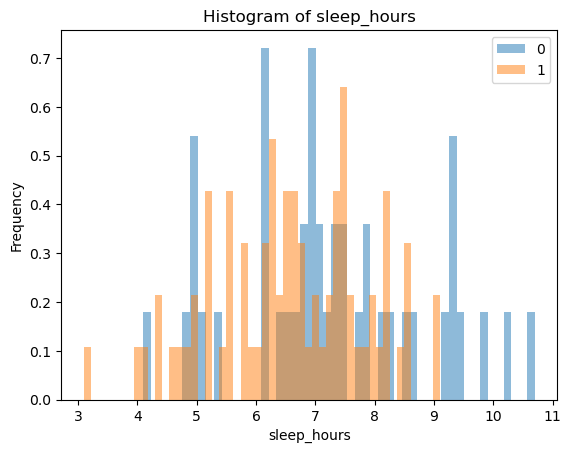

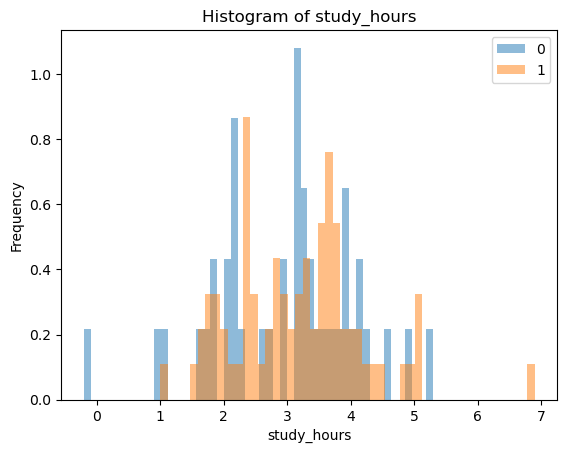

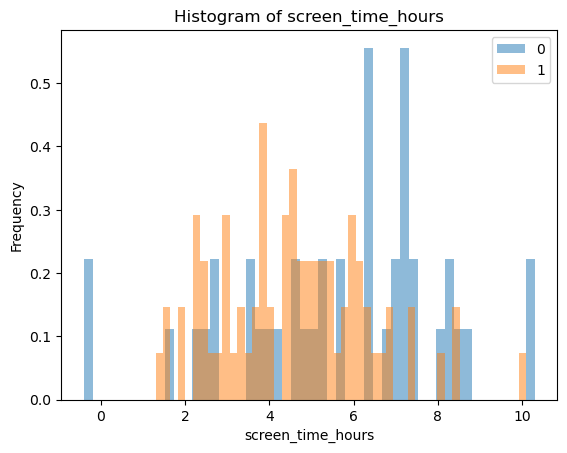

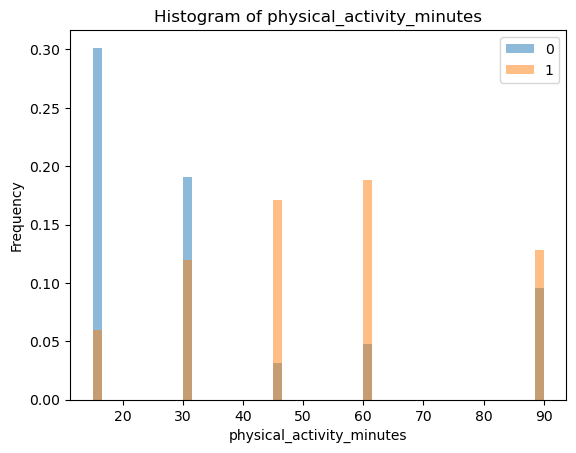

In [12]:
# Define the numeric features
numeric_features = [
    "sleep_hours",
    "study_hours",
    "screen_time_hours",
    "physical_activity_minutes"
]

for feat in numeric_features:
    ax = train_df.groupby("good_well_being")[feat].plot.hist(
        bins=50, alpha=0.5, legend=True, density=True, title="Histogram of " + feat
    )
    plt.xlabel(feat)
    plt.show()

<!-- BEGIN QUESTION -->

## Exercise 1: EDA 
rubric={points}

- Looking at the histograms, we do not observe a clear pattern between the `study_hours` feature and the target. Based on this, would it be reasonable to exclude `study_hours` from the model? Briefly explain your reasoning in 1 to 3 sentences.

_Points:_ 4

Overlapping data between 0 and 11 in terms of range of study. There is no correlation between feature and target but the model might be able to find the pattern so we still might need to keep it.
So we still want to include study hours because there might be a pattern that you can learn between study hours and other fratures.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## Exercise 2: Feature engineering
rubric={points}

Let's add a new feature which might be suitable for this problem. 

**Your tasks:**

- Add a feature called `sleep_study_balance` which is the ratio of `sleep_hours` to   `study_hours` which captures how balanced the student's lifestyle is in terms of sleep and study time.

<div class="alert alert-warning">
⚠️ If you get stuck on this question, move on to the next one. You’ll still be able to complete later exercises with minor adjustments.
</div>

_Points:_ 2

In [13]:
train_df["sleep_study_balance"] = train_df['physical_activity_minutes']/ train_df['screen_time_hours']
test_df["sleep_study_balance"] = test_df['physical_activity_minutes']/ test_df['screen_time_hours']

# Show the updated dataset structure to verify
train_df[['sleep_hours', 'study_hours', 'sleep_study_balance']].head()

,sleep_hours,study_hours,sleep_study_balance
22,7.1,2.9,20.000000
15,6.2,3.4,10.843373
65,9.0,3.8,6.164384
11,6.3,3.8,5.882353
42,6.8,3.2,-100.000000


<!-- END QUESTION -->

<br><br>

## Preprocessing

The code below creates `X_train`, `y_train`, `X_test`, `y_test` and defines a column transformer for the given dataset. 

**No need to write any code on your own in this section. Simply run the cells below before moving on to the next section.**

In [14]:
X_train, y_train = (
    train_df.drop(columns=["good_well_being"]),
    train_df["good_well_being"],
)
X_test, y_test = test_df.drop(columns=["good_well_being"]), test_df["good_well_being"]

In [15]:
# ColumnTransformer for numerical and categorical data
numeric_features = [
    "sleep_hours",
    "study_hours",
    "physical_activity_minutes",
    "coffee_intake",
    "screen_time_hours",
    "sleep_study_balance" # Comment out this line if you weren't able to successfully create this feature in Exercise 2.
]
passthrough_features = ["participated_in_meditation", "friend_support"]
categorical_features = ["mood", "semester"]
drop_features = ["student_id", "recent_post_title"]
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    ("passthrough", passthrough_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("drop", drop_features),
)

<br><br>

Let's extract the feature names of the transformed data and visualize the transformed data as a dataframe. 

In [16]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)
X_train_enc_df.head()

,standardscaler__sleep_hours,standardscaler__study_hours,standardscaler__physical_activity_minutes,standardscaler__coffee_intake,standardscaler__screen_time_hours,standardscaler__sleep_study_balance,passthrough__participated_in_meditation,passthrough__friend_support,onehotencoder__mood_Anxious,onehotencoder__mood_Energetic,onehotencoder__mood_Happy,onehotencoder__mood_Neutral,onehotencoder__mood_Tired,onehotencoder__semester_Fall,onehotencoder__semester_Spring,onehotencoder__semester_Summer
0,0.197089,-0.185408,1.724745,2.313012,-0.225031,0.686676,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.440205,0.292037,1.724745,1.325249,1.591149,0.092340,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.542489,0.673993,-0.049278,-0.650277,1.113207,-0.211363,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.369395,0.673993,-0.640620,-0.650277,0.061734,-0.229669,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.015342,0.101059,-0.640620,-0.650277,-2.519154,-7.102253,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [17]:
# Make sure you have the right number of rows and columns in the training data
assert X_train_enc_df.shape == (120, 16)

# Make sure you have the right number of rows and columns in the test data
assert X_test_enc_df.shape == (30, 16)

# Make sure that you have no null values
assert X_train_enc_df.isnull().sum().sum() == 0

<br><br>

## Modeling

We'll be using three models on this toy dataset. 

**No need to write any code in this section-simply run the cells below before moving on to the next section.**

In [18]:
models = {
    "dummy": DummyClassifier(strategy="most_frequent", random_state=123),
    "Logistic Regression": make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=123),
    ),
    "Random Forest": make_pipeline(
        preprocessor, RandomForestClassifier(class_weight="balanced", random_state=123)
    ),
    "LGBM": make_pipeline(
        preprocessor,
        LGBMClassifier(
            class_weight="balanced",
            learning_rate=0.01,
            num_leaves=8,
            max_depth=3,
            min_data_in_leaf=5,
            min_child_weight=1,
            min_split_gain=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=123,
            verbose=-1,
        ),
    ),
}

In [19]:
# The function borrowed from the lecture notes.
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append(
            (f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i]))
        )

    return pd.Series(data=out_col, index=mean_scores.index)


In [20]:
results_df = None
results_dict = {}
for model_name, model in models.items():
    results_dict[model_name] = mean_std_cross_val_scores(
        model,
        X_train,
        y_train,
        return_train_score=True,
        scoring="balanced_accuracy",
        cv=5,
    )

results_df = pd.DataFrame(results_dict).T
results_df

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

,fit_time,score_time,test_score,train_score
dummy,0.000 (+/- 0.000),0.001 (+/- 0.000),0.500 (+/- 0.000),0.500 (+/- 0.000)
Logistic Regression,0.006 (+/- 0.002),0.002 (+/- 0.000),0.729 (+/- 0.074),0.855 (+/- 0.024)
Random Forest,0.068 (+/- 0.002),0.004 (+/- 0.000),0.710 (+/- 0.102),1.000 (+/- 0.000)
LGBM,0.114 (+/- 0.025),0.004 (+/- 0.002),0.796 (+/- 0.063),0.930 (+/- 0.020)


<br><br>

Now let's try a stacking model. The code below trains sklearn’s `StackingClassifier` and appends a row to the results dataframe, showing the results from the stacking model.

In [21]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    list(models.items()),
    final_estimator=LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=123
    )
)
results_dict["stacking_model"] = mean_std_cross_val_scores(stacking_model, X_train, y_train, return_train_score=True, scoring="balanced_accuracy")  # SOLUTION
pd.DataFrame(results_dict).T

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

,fit_time,score_time,test_score,train_score
dummy,0.000 (+/- 0.000),0.001 (+/- 0.000),0.500 (+/- 0.000),0.500 (+/- 0.000)
Logistic Regression,0.006 (+/- 0.002),0.002 (+/- 0.000),0.729 (+/- 0.074),0.855 (+/- 0.024)
Random Forest,0.068 (+/- 0.002),0.004 (+/- 0.000),0.710 (+/- 0.102),1.000 (+/- 0.000)
LGBM,0.114 (+/- 0.025),0.004 (+/- 0.002),0.796 (+/- 0.063),0.930 (+/- 0.020)
stacking_model,1.237 (+/- 0.111),0.011 (+/- 0.001),0.782 (+/- 0.058),0.955 (+/- 0.015)


Let's examine the coefficients of the constituent classifiers within the stacking model.

<br><br>

<!-- BEGIN QUESTION -->

## Exercise 3: Coefficients of `StackingClassifier`
rubric={points}

**Your tasks:**

1.	Display the coefficients associated with each consistituent classifier in the final estimator (meta-model) within the stacking classifier.

In [22]:
# Fitting the model so that you can access the coefficients. 
stacking_model.fit(X_train, y_train)

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fit

,estimators,"[('dummy', ...), ('Logistic Regression', ...), ...]"
,final_estimator,LogisticRegre...dom_state=123)
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,strategy,'most_frequent'
,random_state,123
,constant,None
,transformers,"[('standardscaler', ...), ('passthrough', ...), ...]"


<div class="alert alert-warning">
⚠️ If you’re spending too much time on this question, feel free to move on. The following questions do not depend on this one.
</div>

_Points:_ 4

In [ ]:
# 1. Display the coefficients associated with each consistituent classifier in the final estimator (meta-model) within the stacking classifier.
# pd.DataFrame({
#     "Classifier": list(models.keys()),
#     "Coefficient": stacking_model.final_estimator_.coef_[0]
# })


pd.DataFrame(
    data=stacking_model.final_estimator_.coef_.flatten(),
    index=models.keys(),
    columns=["Coefficient"],
).sort_values("Coefficient", ascending=False)




,Coefficient
LGBM,2.243621
Random Forest,1.815537
Logistic Regression,1.289118
dummy,-0.000442


In [37]:
meta = stacking_model.final_estimator_
print("Intercept:", meta.intercept_)
print("Coefficients:", meta.coef_)

Intercept: [-2.95550022]
Coefficients: [[-4.41535476e-04  1.28911774e+00  1.81553701e+00  2.24362098e+00]]


<!-- END QUESTION -->

<br><br><br><br>

Next, we will attempt to interpret our models. 

Assuming that the variable `feature_names` has the correct feature names, the code below displays coefficients associated with a logistic regression model.

In [24]:
lr_pipe = models["Logistic Regression"].fit(X_train, y_train)
rf_pipe = models["Random Forest"].fit(X_train, y_train)

In [25]:
lr_coefs = lr_pipe.named_steps["logisticregression"].coef_.flatten()
pd.DataFrame(lr_coefs, index=feature_names, columns=["coefficient"]).sort_values(
    by="coefficient", ascending=False
)

,coefficient
standardscaler__sleep_study_balance,1.257729
passthrough__friend_support,1.022701
onehotencoder__mood_Energetic,0.779444
standardscaler__physical_activity_minutes,0.709126
onehotencoder__mood_Anxious,0.519542
onehotencoder__mood_Neutral,0.303403
onehotencoder__semester_Fall,0.245509
standardscaler__study_hours,0.116933
standardscaler__coffee_intake,0.074840
onehotencoder__semester_Spring,-0.111192


<!-- BEGIN QUESTION -->

## Exercise 4: Interpretation of logistic regression coefficients
rubric={points}

**Your tasks:**

- In logistic regression, the `feature standardscaler__physical_activity_minutes` has a coefficient of 1.067984. Interpret this coefficient: does it imply that adding one minute to this feature increases the raw prediction by 1.067? Briefly explain.

_Points:_ 4

No, Adding 1 hour doesnt necessarily means it will increase it because the feature is scaled. it will increase 1 scalled unit of this feature decrease the prediction by -0.75.

<!-- END QUESTION -->

<br><br>

Below are the feature importances for a random forest model.

In [26]:
rf_feat_importances = rf_pipe.named_steps[
    "randomforestclassifier"
].feature_importances_ 
pd.DataFrame(rf_feat_importances, index=feature_names, columns=["feat_importance"]).sort_values(
    by="feat_importance", ascending=False
)

,feat_importance
standardscaler__sleep_study_balance,0.256990
standardscaler__screen_time_hours,0.170275
standardscaler__physical_activity_minutes,0.146366
standardscaler__sleep_hours,0.126492
standardscaler__study_hours,0.079664
standardscaler__coffee_intake,0.049566
onehotencoder__mood_Tired,0.033128
passthrough__friend_support,0.020589
onehotencoder__mood_Neutral,0.018815
passthrough__participated_in_meditation,0.018673


<!-- BEGIN QUESTION -->

## Exercise 5: Interpretation of random forest feature importances  
rubric={points}

1.	Similar to logistic regression, our random forest model identified `standardscaler__screen_time_hours` as one of the most important features, with an importance value of 0.208816. Does this positive importance value indicate that increasing screen time would result in a higher prediction score (suggesting better well-being)?

_Points:_ 4

No, Because Feature importance does not have a direction. It is based on a tree based model. It just shows how much the feature affect the prediction.

<!-- END QUESTION -->

<br><br>

## SHAP: Individual predictions 

Assuming that you have `X_train_enc_df` and `X_test_enc_df` defined, the code below extracts the SHAP values and shows force plot and a dependence plot. 

In [27]:
X_train_enc_df.head()

,standardscaler__sleep_hours,standardscaler__study_hours,standardscaler__physical_activity_minutes,standardscaler__coffee_intake,standardscaler__screen_time_hours,standardscaler__sleep_study_balance,passthrough__participated_in_meditation,passthrough__friend_support,onehotencoder__mood_Anxious,onehotencoder__mood_Energetic,onehotencoder__mood_Happy,onehotencoder__mood_Neutral,onehotencoder__mood_Tired,onehotencoder__semester_Fall,onehotencoder__semester_Spring,onehotencoder__semester_Summer
0,0.197089,-0.185408,1.724745,2.313012,-0.225031,0.686676,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.440205,0.292037,1.724745,1.325249,1.591149,0.092340,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.542489,0.673993,-0.049278,-0.650277,1.113207,-0.211363,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.369395,0.673993,-0.640620,-0.650277,0.061734,-0.229669,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.015342,0.101059,-0.640620,-0.650277,-2.519154,-7.102253,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [28]:
X_test_enc_df.head()

,standardscaler__sleep_hours,standardscaler__study_hours,standardscaler__physical_activity_minutes,standardscaler__coffee_intake,standardscaler__screen_time_hours,standardscaler__sleep_study_balance,passthrough__participated_in_meditation,passthrough__friend_support,onehotencoder__mood_Anxious,onehotencoder__mood_Energetic,onehotencoder__mood_Happy,onehotencoder__mood_Neutral,onehotencoder__mood_Tired,onehotencoder__semester_Fall,onehotencoder__semester_Spring,onehotencoder__semester_Summer
0,1.754921,-1.617741,-1.231961,-0.650277,-0.177237,-0.399823,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.865069,-0.280897,-0.640620,-0.650277,-0.225031,-0.178761,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.330058,-0.471874,-0.049278,0.337486,0.491882,-0.124671,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.197089,-0.758341,1.724745,-0.650277,-1.467681,2.463098,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.197089,0.005570,0.542063,0.337486,-0.655179,0.470317,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [29]:
import shap

# SHAP: Compute and plot SHAP values
model = LGBMClassifier(
    class_weight="balanced",
    learning_rate=0.01,
    num_leaves=8,
    max_depth=3,
    min_data_in_leaf=5,
    min_child_weight=1,
    min_split_gain=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=123,
    verbose=-1,
)
model.fit(X_train_enc_df, y_train)
explainer = shap.TreeExplainer(model)
train_shap_values = explainer(X_train_enc_df)
test_shap_values = explainer(X_test_enc_df)

Let's get prediction for an example. 

In [30]:
ex1_idx = 1
X_test_enc[ex1_idx]

array([-0.86506855, -0.28089653, -0.64061954, -0.65027735, -0.22503112,
       -0.17876076,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ])

In [31]:
y_test.iloc[ex1_idx]

np.int64(0)

The `y` value for the example is 0, i.e., the student well-being is poor. 

In [32]:
model.predict_proba(X_test_enc)[ex1_idx]

/opt/miniconda3/envs/cpsc330/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([0.54652196, 0.45347804])

The model has a higher probability of 0.618 for poor mental well-being. 

<br><br>

<!-- BEGIN QUESTION -->

## Exercise 6: Explaining individual predictions

Below is the waterfall plot for this student. Explain the prediction for this student using the plot below. 

**Your tasks:**

1. Explain a specific prediction given by the waterfall plot below in 2 to 3 sentences. 

_Points:_ 5

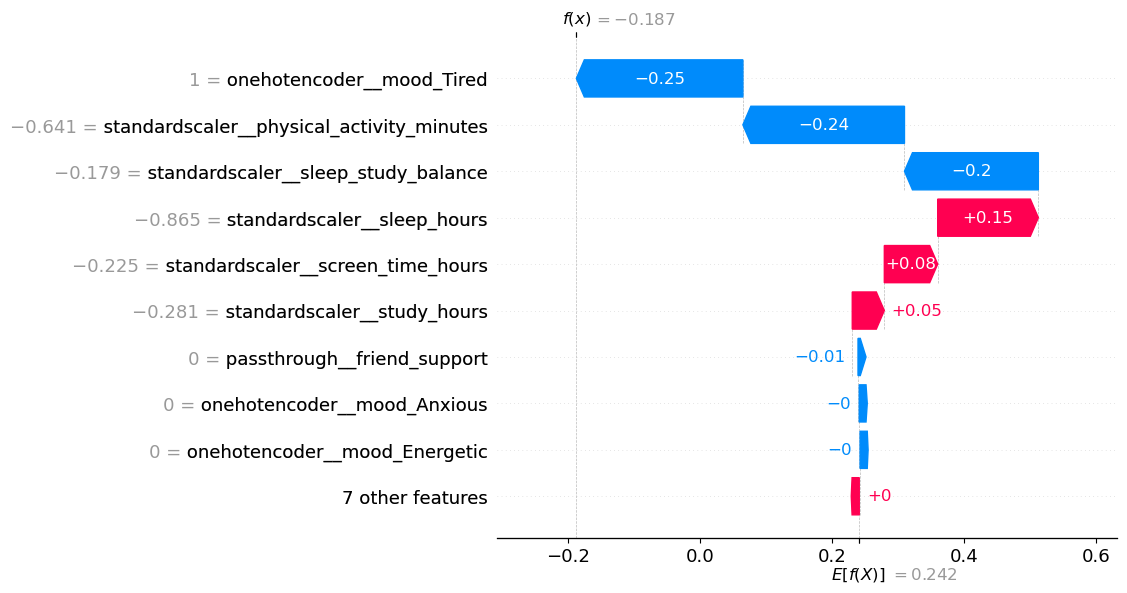

In [33]:
shap.plots.waterfall(test_shap_values[ex1_idx])

the prediction is closer to 1, indicates good well being. excercise hours contributes the most to the positive prediction and likely has high excer

<!-- END QUESTION -->

<br><br>

## **Wrap-up**

Great job! In this exam, you have completed the following:
- Exercise 1: Explored the data.
- Exercise 2: Engineered a new feature.
- Exercise 3: Trained a stacking model and displayed coefficients for constituent models in the stacking model's meta-model.
- Exercise 4: Analyzed and interpreted logistic regression coefficients.
- Exercise 5: Examined feature importances for the random forest model.
- Exercise 6: Interpreted SHAP plots for the best-performing LGBM model.

Please review to ensure you've completed all exercises.

<br><br>

<div class="alert alert-info">
    
## Saving instructions
<hr>

**After you are finished in the workspace, remember to go back to the PrairieLearn page and click "Save". Once you do, you will be able to see a preview of your HTML rendered notebook. This is the file that will be graded, so make sure it appears as it should. If you spot any problems, you can "Report an issue" with this question.**